# 01 Python Data Processing and Analytics
This notebook loads the NorthStar dataset, cleans inconsistent zones, joins related CSV files, creates analytical fields, produces summary tables and generates charts for the report.

In [5]:
# Install packages if running in a fresh Colab runtime
!pip -q install pandas numpy matplotlib

In [6]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# In Colab, upload the CSV files into /content/northstar_dataset or change this path.
DATA_DIR = Path("/content/northstar_dataset")
if not DATA_DIR.exists():
    from google.colab import files
    print("Upload all CSV files from data/raw when prompted.")
    uploaded = files.upload()
    DATA_DIR.mkdir(exist_ok=True)
    for name, data in uploaded.items():
        Path(name).rename(DATA_DIR / name)
print("Using data folder:", DATA_DIR)

Upload all CSV files from data/raw when prompted.


Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving README.txt to README.txt
Saving vehicles.csv to vehicles.csv
Using data folder: /content/northstar_dataset


In [7]:
files = {
    "orders": "orders.csv", "deliveries": "deliveries.csv", "complaints": "complaints.csv",
    "customers": "customers.csv", "drivers": "drivers.csv", "hubs": "hubs.csv",
    "incidents": "incidents.csv", "vehicles": "vehicles.csv", "app_events": "app_events.csv"
}
data = {name: pd.read_csv(DATA_DIR / filename) for name, filename in files.items()}
for name, df in data.items():
    print(name, df.shape)
    display(df.head(3))

orders (1250, 11)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0


deliveries (950, 13)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51


complaints (320, 10)


...

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0


vehicles (120, 8)


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1


app_events (640, 10)


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1


In [8]:
files = {
    "orders": "orders.csv", "deliveries": "deliveries.csv", "complaints": "complaints.csv",
    "customers": "customers.csv", "drivers": "drivers.csv", "hubs": "hubs.csv",
    "incidents": "incidents.csv", "vehicles": "vehicles.csv", "app_events": "app_events.csv"
}
data = {name: pd.read_csv(DATA_DIR / filename) for name, filename in files.items()}

In [9]:
def normalise_zone(value):
    if pd.isna(value):
        return value
    return str(value).strip().title()

for df, col in [(data["orders"], "pickup_zone"), (data["orders"], "dropoff_zone"),
                (data["drivers"], "base_zone"), (data["vehicles"], "assigned_zone"),
                (data["hubs"], "zone"), (data["app_events"], "zone_context")]:
    df[col] = df[col].apply(normalise_zone)

In [10]:
orders = data["orders"]
deliveries = data["deliveries"]
complaints = data["complaints"]
incidents = data["incidents"]

complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    max_resolution_days=("resolution_days", "max")
).reset_index()

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_incident_resolved_hours=("resolved_hours", "mean")
).reset_index()

integrated = deliveries.merge(orders, on="order_id", how="left") \
    .merge(data["hubs"], on="hub_id", how="left") \
    .merge(data["drivers"], on="driver_id", how="left") \
    .merge(data["vehicles"], on="vehicle_id", how="left") \
    .merge(complaint_summary, on="order_id", how="left") \
    .merge(incident_summary, on="delivery_id", how="left")

integrated[["complaint_count", "total_compensation", "max_resolution_days", "incident_count"]] = integrated[["complaint_count", "total_compensation", "max_resolution_days", "incident_count"]].fillna(0)
integrated["problem_delivery"] = integrated["delivery_status"].isin(["Delayed", "Failed"]).astype(int)
integrated["failed_delivery"] = (integrated["delivery_status"] == "Failed").astype(int)
print(integrated.shape)
display(integrated.head())

(950, 48)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,odometer_km,maintenance_status,telematics_version,complaint_count,total_compensation,max_resolution_days,incident_count,avg_incident_resolved_hours,problem_delivery,failed_delivery
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,29849,Active,v2.2,0.0,0.0,0.0,1.0,5.6,1,1
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,78468,Active,v2.2,0.0,0.0,0.0,0.0,NaN,0,0
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,15278,Active,v2.2,0.0,0.0,0.0,0.0,NaN,0,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,85635,Active,v2.1,0.0,0.0,0.0,0.0,NaN,1,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,210683,InRepair,v2.0,0.0,0.0,0.0,0.0,NaN,0,0


In [11]:
hub_performance = integrated.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    problem_rate=("problem_delivery", "mean"),
    failure_rate=("failed_delivery", "mean"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    avg_overrides=("manual_route_override_count", "mean"),
    proof_missing_rate=("proof_of_completion_missing", "mean"),
    complaints=("complaint_count", "sum"),
    incidents=("incident_count", "sum"),
    avg_cost=("fuel_or_charge_cost", "mean")
).reset_index().sort_values("problem_rate", ascending=False)
display(hub_performance)

,hub_id,hub_name,zone,total_deliveries,problem_rate,failure_rate,avg_rating,avg_overrides,proof_missing_rate,complaints,incidents,avg_cost
4,H05,Central Core,Central,115,0.417391,0.200000,3.669558,0.947826,0.086957,30.0,39.0,13.686000
5,H06,Airport Hub,Airport,104,0.403846,0.144231,3.882136,0.913462,0.096154,23.0,32.0,13.319231
7,H08,Midtown Relay,Central,128,0.375000,0.203125,3.884560,1.109375,0.078125,35.0,38.0,11.708203
3,H04,West Gate,West,127,0.346457,0.125984,3.915476,0.874016,0.055118,28.0,34.0,13.167008
1,H02,South Link,South,106,0.339623,0.094340,3.950952,0.915094,0.075472,18.0,33.0,12.565000
6,H07,Riverside Hub,Riverside,115,0.339130,0.121739,3.881858,1.052174,0.078261,33.0,35.0,12.922087
0,H01,North Exchange,North,136,0.316176,0.125000,3.840593,1.029412,0.044118,32.0,31.0,12.755809
2,H03,East Dock,East,119,0.285714,0.092437,3.895862,0.890756,0.075630,33.0,38.0,12.744202


In [19]:
service_performance = integrated.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    problem_rate=("problem_delivery", "mean"),
    failure_rate=("failed_delivery", "mean"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_order_value=("order_value", "mean"),
    avg_cost=("fuel_or_charge_cost", "mean"),
    complaints=("complaint_count", "sum")
).reset_index().sort_values("problem_rate", ascending=False)
display(service_performance)

,service_type,total_orders,problem_rate,failure_rate,avg_customer_rating,avg_order_value,avg_cost,complaints
0,Business,126,0.420635,0.198413,3.847280,97.454206,13.142143,33.0
1,Medical,108,0.351852,0.148148,3.837685,86.526667,12.772963,22.0
4,Retail,224,0.348214,0.125000,3.872545,86.807411,12.974420,57.0
3,Passenger,262,0.347328,0.145038,3.845253,97.188397,12.399084,64.0
2,Parcel,230,0.321739,0.108696,3.901637,90.154087,13.082652,56.0


In [13]:
complaint_types = complaints["complaint_type"].value_counts().reset_index()
complaint_types.columns = ["complaint_type", "count"]
app_performance = data["app_events"].groupby("event_type").agg(
    events=("event_id", "count"),
    success_rate=("success_flag", "mean"),
    avg_latency_ms=("api_latency_ms", "mean")
).reset_index().sort_values(["success_rate", "avg_latency_ms"])
display(complaint_types)
display(app_performance)

,complaint_type,count
0,Delay,101
1,MissedPickup,64
2,AppIssue,53
3,DriverBehaviour,51
4,SupportExperience,20
5,Billing,16
6,Damage,15


,event_type,events,success_rate,avg_latency_ms
1,chat_escalated,38,0.500000,478.131579
5,payment_retry,69,0.724638,472.681159
0,cancel_attempt,28,1.000000,417.142857
4,eta_refresh,105,1.000000,452.152381
6,search_route,99,1.000000,456.505051
7,track_order,138,1.000000,460.710145
2,chat_opened,88,1.000000,478.329545
3,delivery_instruction_update,75,1.000000,496.293333


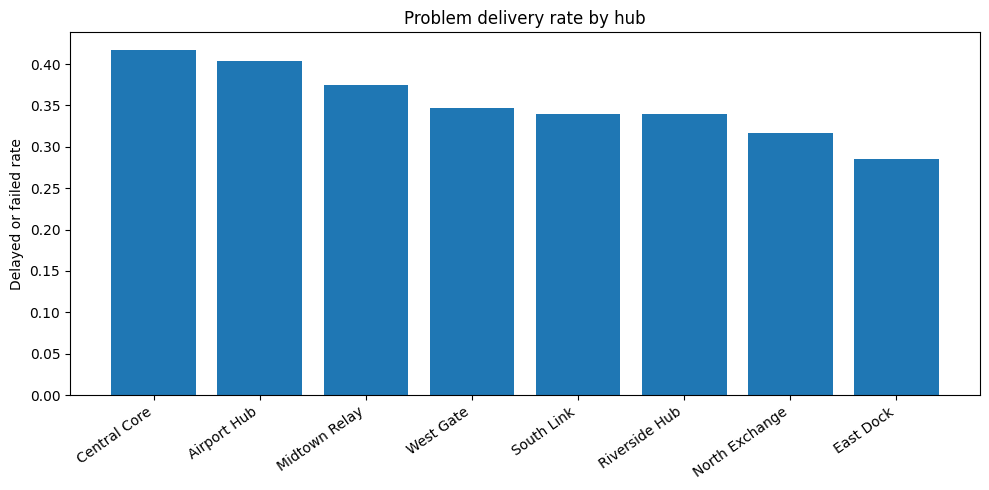

In [14]:
plt.figure(figsize=(10,5))
plt.bar(hub_performance["hub_name"], hub_performance["problem_rate"])
plt.title("Problem delivery rate by hub")
plt.ylabel("Delayed or failed rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

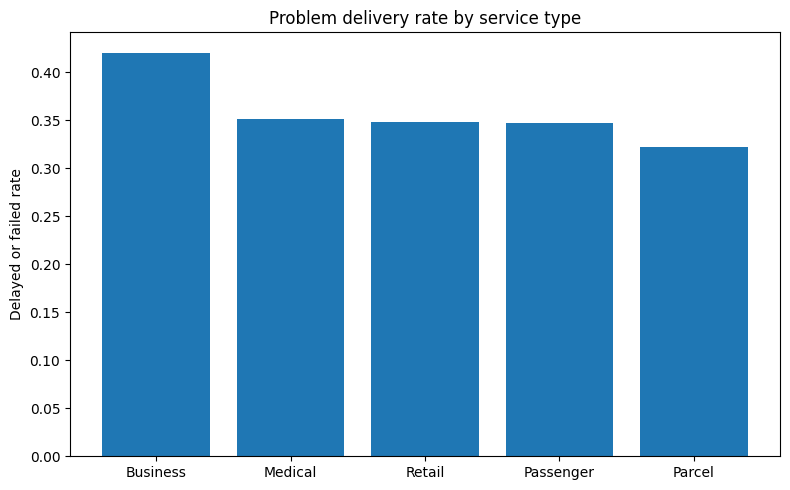

In [15]:
plt.figure(figsize=(8,5))
plt.bar(service_performance["service_type"], service_performance["problem_rate"])
plt.title("Problem delivery rate by service type")
plt.ylabel("Delayed or failed rate")
plt.tight_layout()
plt.show()

In [20]:

complaint_counts = complaints.groupby(["complaint_type", "severity"]).agg(
    complaint_count=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index().sort_values("complaint_count", ascending=False)

display(complaint_counts)

,complaint_type,severity,complaint_count,avg_resolution_days,total_compensation
11,Delay,Medium,56,5.964286,964.87
17,MissedPickup,Medium,37,6.162162,644.80
14,DriverBehaviour,Medium,31,5.419355,476.29
10,Delay,Low,27,6.481481,220.43
2,AppIssue,Medium,25,7.360000,386.58
9,Delay,High,18,12.444444,511.54
15,MissedPickup,High,16,11.562500,689.11
12,DriverBehaviour,High,16,13.750000,460.63
1,AppIssue,Low,15,6.066667,185.55
0,AppIssue,High,13,13.923077,408.59


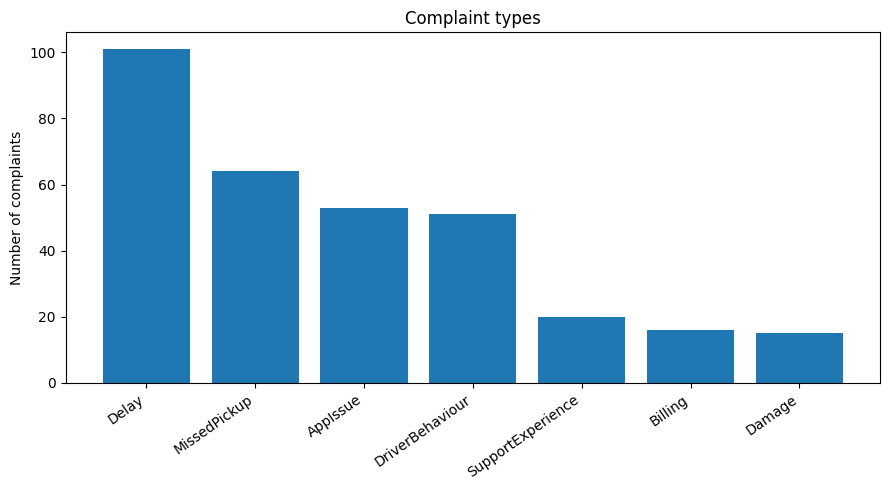

In [16]:
plt.figure(figsize=(9,5))
plt.bar(complaint_types["complaint_type"], complaint_types["count"])
plt.title("Complaint types")
plt.ylabel("Number of complaints")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [17]:
correlation_cols = ["problem_delivery", "manual_route_override_count", "proof_of_completion_missing",
                    "route_distance_km", "training_score", "driver_rating", "battery_health_pct",
                    "incident_count", "customer_rating_post_delivery", "fuel_or_charge_cost"]
correlations = integrated[correlation_cols].corr()["problem_delivery"].sort_values(ascending=False)
display(correlations)

,problem_delivery
problem_delivery,1.000000
proof_of_completion_missing,0.380061
manual_route_override_count,0.060928
fuel_or_charge_cost,0.051150
training_score,0.037411
route_distance_km,0.024158
battery_health_pct,-0.029684
incident_count,-0.039378
driver_rating,-0.103124
customer_rating_post_delivery,-0.637526


In [18]:
OUTPUT_DIR = Path("/content/northstar_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
hub_performance.to_csv(OUTPUT_DIR / "hub_performance.csv", index=False)
service_performance.to_csv(OUTPUT_DIR / "service_performance.csv", index=False)
integrated.to_csv(OUTPUT_DIR / "integrated_delivery_analysis.csv", index=False)
print("Saved outputs to", OUTPUT_DIR)

Saved outputs to /content/northstar_outputs
